In [1]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
from sklearn.metrics import f1_score, classification_report, multilabel_confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import torch
import gc
import warnings
import joblib

warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Logistic Regression (3x Penalty + Negation) - Final Model

#### Load TF-IDF Model & Test Set

In [2]:
# Load models
tfidf = joblib.load('../models/tfidf_vectorizer.pkl')
tfidf_model = joblib.load('../models/tfidf_logreg_final.pkl')

# Load saved test set
X_test = sp.load_npz('../data/tfidf_X_test.npz')
y_test = np.load('../data/tfidf_y_test.npy')
print(f"Test size: {X_test.shape[0]:,}")

Test size: 2,261,438


## Test Set Results

In [3]:
# 14 binary labels (7 aspects x 2 sentiments)
aspect_cols = [
             'product_quality_positive', 'product_quality_negative',
             'service_positive', 'service_negative',
             'wait_time_positive', 'wait_time_negative',
             'price_value_positive', 'price_value_negative',
             'cleanliness_positive', 'cleanliness_negative',
             'atmosphere_positive', 'atmosphere_negative',
             'general_positive', 'general_negative'
             ]

# Evaluate
y_pred = tfidf_model.predict(X_test)
print("Logistic Regression (Weighted Classes - 3x Penalty + Negation) - Test Set:")
print()
print(f"F1 Score (weighted): {f1_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
print(f"F1 Score (macro):    {f1_score(y_test, y_pred, average='macro', zero_division=0):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=aspect_cols, zero_division=0))

Logistic Regression (Weighted Classes - 3x Penalty + Negation) - Test Set:

F1 Score (weighted): 0.8817
F1 Score (macro):    0.7846

Classification Report:
                          precision    recall  f1-score   support

product_quality_positive       0.88      0.96      0.92    699524
product_quality_negative       0.64      0.74      0.69    170629
        service_positive       0.90      0.97      0.93    557547
        service_negative       0.71      0.80      0.75    146304
      wait_time_positive       0.82      0.91      0.86    280513
      wait_time_negative       0.64      0.75      0.69    105530
    price_value_positive       0.85      0.94      0.89    255333
    price_value_negative       0.62      0.69      0.65     79571
    cleanliness_positive       0.87      0.94      0.90    114739
    cleanliness_negative       0.68      0.64      0.66     35854
     atmosphere_positive       0.86      0.96      0.91    186086
     atmosphere_negative       0.51      0.55      

## Manually Labeled Validation Set Results

In [4]:
# Load validation set
df_val = pd.read_csv("../data/manual_absa_eval_reviews.csv")

# 14 binary labels (7 aspects x 2 sentiments)
aspect_cols = [
    'product_quality_positive', 'product_quality_negative',
    'service_positive', 'service_negative',
    'wait_time_positive', 'wait_time_negative',
    'price_value_positive', 'price_value_negative',
    'cleanliness_positive', 'cleanliness_negative',
    'atmosphere_positive', 'atmosphere_negative',
    'general_positive', 'general_negative'
]

# Predict
X = tfidf.transform(df_val["text"].fillna(""))
y_true_val = df_val[aspect_cols].values
y_pred_val = tfidf_model.predict(X)

print("Logistic Regression (Weighted Classes - 3x Penalty + Negation) - Validation Set (Manual Labels):")
print()
print(f"F1 Score (weighted): {f1_score(y_true_val, y_pred_val, average='weighted'):.4f}")
print(f"F1 Score (macro):    {f1_score(y_true_val, y_pred_val, average='macro'):.4f}")
print()
print("Classification Report:")
print(classification_report(y_true_val, y_pred_val, target_names=aspect_cols, zero_division=0))

Logistic Regression (Weighted Classes - 3x Penalty + Negation) - Validation Set (Manual Labels):

F1 Score (weighted): 0.5948
F1 Score (macro):    0.5636

Classification Report:
                          precision    recall  f1-score   support

product_quality_positive       0.69      0.61      0.65       708
product_quality_negative       0.53      0.59      0.56       475
        service_positive       0.71      0.71      0.71       529
        service_negative       0.80      0.68      0.74       626
      wait_time_positive       0.29      0.87      0.44       101
      wait_time_negative       0.43      0.79      0.55       180
    price_value_positive       0.48      0.75      0.59       196
    price_value_negative       0.67      0.65      0.66       298
    cleanliness_positive       0.62      0.84      0.71        76
    cleanliness_negative       0.65      0.47      0.55       127
     atmosphere_positive       0.52      0.45      0.48       216
     atmosphere_negative     

# Final Model — Validation Set Analysis

- Macro F1 drops from 0.785 on test to 0.564 on validation, a gap of 0.22 points, indicating the model learned patterns specific to the weakly-supervised pseudo-labels rather than true human annotation behavior
- Wait time positive precision collapses to 0.29 on validation despite 0.82 on test, suggesting the keyword-based pseudo-labels for this aspect are noisy and do not reflect how humans actually identify wait time sentiment
- Atmosphere negative remains the hardest label at F1 0.22, consistent with test set findings, confirming this is a fundamental limitation of bag-of-words representations rather than a data quantity issue
- The model generalizes reasonably on high-frequency aspects like service negative (F1 0.74) and price value negative (F1 0.66), where sentiment language is more explicit and consistent between pseudo and human labels

# Figures

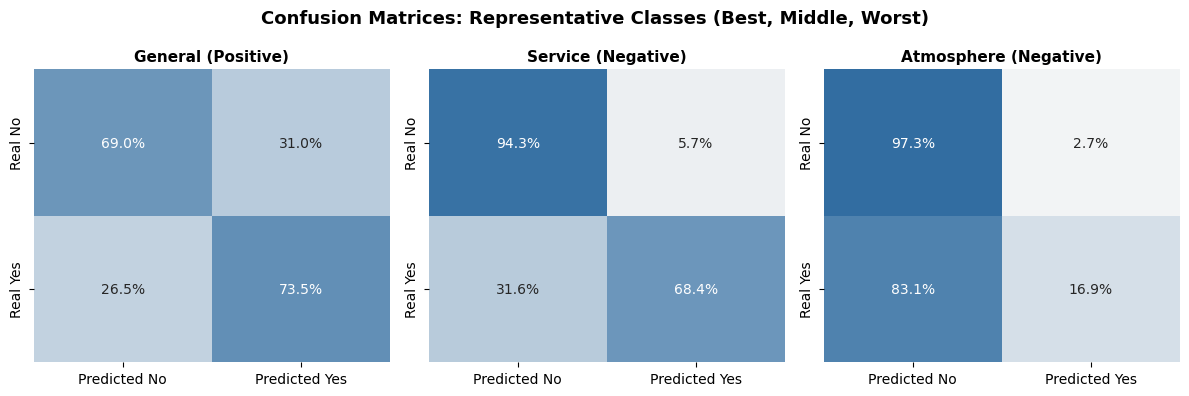

In [5]:
# Figure 2 
# Confusion Matrices (Validation Set)

# Compute on validation set
mcm = multilabel_confusion_matrix(y_true_val, y_pred_val)

cmap = LinearSegmentedColormap.from_list('custom', ['#f7f7f7', '#2d6a9f'])

selected = ['general_positive', 'service_negative', 'atmosphere_negative']
selected_idx = [aspect_cols.index(s) for s in selected]
titles = ['General (Positive)', 'Service (Negative)', 'Atmosphere (Negative)']

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, idx, title in zip(axes, selected_idx, titles):
    tn, fp, fn, tp = mcm[idx].ravel()
    cm_data = np.array([[tn, fp], [fn, tp]])
    cm_pct = cm_data / cm_data.sum(axis=1, keepdims=True) * 100

    sns.heatmap(cm_pct, annot=True, fmt='.1f', ax=ax, cmap=cmap,
                xticklabels=['Predicted No', 'Predicted Yes'],
                yticklabels=['Real No', 'Real Yes'],
                cbar=False, vmin=0, vmax=100)
    ax.set_title(title, fontsize=11, fontweight='bold')

    for text in ax.texts:
        text.set_text(text.get_text() + '%')

plt.suptitle('Confusion Matrices: Representative Classes (Best, Middle, Worst)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/figure2_tfidf_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 2 (TF-IDF confusion matrices):

- General positive classifies well on validation but atmosphere negative recall drops to 17%, the model's weakest label
- Bag-of-words representations cannot resolve contextual ambiguity in atmosphere language

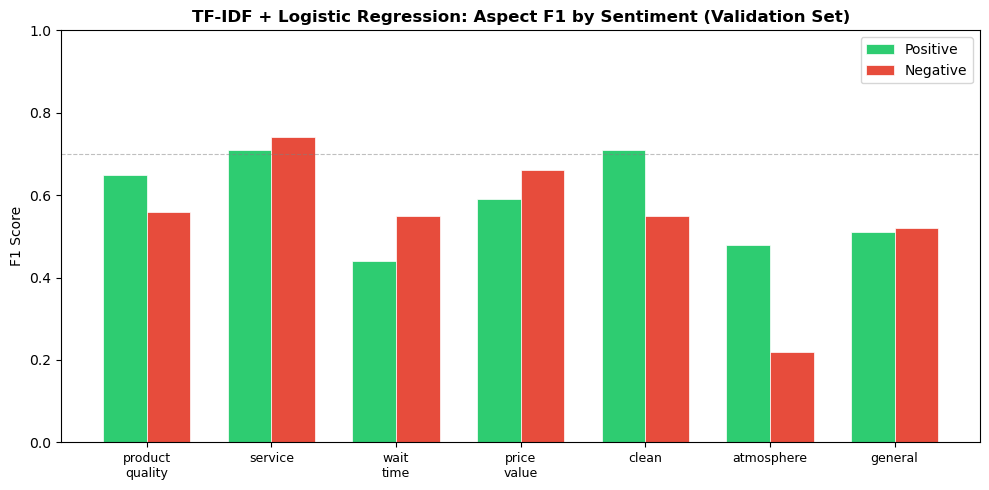

In [6]:
# Figure 3 
# TF-IDF Aspect F1 by Sentiment (Validation Set)

aspects = ['product\nquality', 'service', 'wait\ntime', 'price\nvalue', 'clean', 'atmosphere', 'general']
pos_f1  = [0.65, 0.71, 0.44, 0.59, 0.71, 0.48, 0.51]
neg_f1  = [0.56, 0.74, 0.55, 0.66, 0.55, 0.22, 0.52]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(aspects))
width = 0.35
ax.bar(x - width/2, pos_f1, width, label='Positive', color='#2ecc71', edgecolor='white', linewidth=0.5)
ax.bar(x + width/2, neg_f1, width, label='Negative', color='#e74c3c', edgecolor='white', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(aspects, fontsize=9)
ax.set_ylim(0.0, 1.0)
ax.set_title('TF-IDF + Logistic Regression: Aspect F1 by Sentiment (Validation Set)', fontweight='bold')
ax.set_ylabel('F1 Score')
ax.legend()
ax.axhline(0.7, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig('../figures/figure3_tfidf_aspect_f1.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 3 (TF-IDF aspect F1 bar):

- Service is the strongest aspect with both positive and negative labels above 0.70, while atmosphere negative (F1 0.22) is the clear outlier
- Positive labels generally outperform their negative counterparts, with wait time and atmosphere showing the largest sentiment gaps